In [10]:
import pandas as pd
from marginal_emissions.core.msar import MSARAnalyzer
from marginal_emissions.utils.helper import *
from pyprojroot import here

root = here()

In [4]:
test = pd.read_csv(f'{root}/data/test/test_final_tennet_1000.csv', index_col=0, delimiter=',')
test.index = pd.to_datetime(test.index, format='ISO8601')
test = test.asfreq('15min')

In [5]:
analyzer = MSARAnalyzer(data=test)

In [6]:
analyzer.prepare()

[INFO][95530][2026-03-12 22:12:34][msar.py][prepare] Preparing data...
[INFO][95530][2026-03-12 22:12:34][msar.py][_set_types] Setting index to datetime...
[INFO][95530][2026-03-12 22:12:34][msar.py][_set_types] Setting columns to numeric...
[INFO][95530][2026-03-12 22:12:34][msar.py][_set_types] Setting frequency to 15min...
[INSPECTION]
  - Index Type: datetime64[ns, UTC]
  - Duplicates: 0
  - NaNs: 0
  - Delta Gen Type: float64
  - Neg. Gen: 289
  - Delta Emi Type: float64
  - Neg. Emi: 371


In [8]:
analyzer.fit_compute()

[INFO][95530][2026-03-12 22:12:55][msar.py][fit_compute] Fitting model and computing MEF for 101 observations...



Analyzing None: 100%|██████████| 101/101 [03:10<00:00,  1.88s/it][A


[INFO][95530][2026-03-12 22:16:50][msar.py][fit_compute] Finished model fitting and MEF computation!


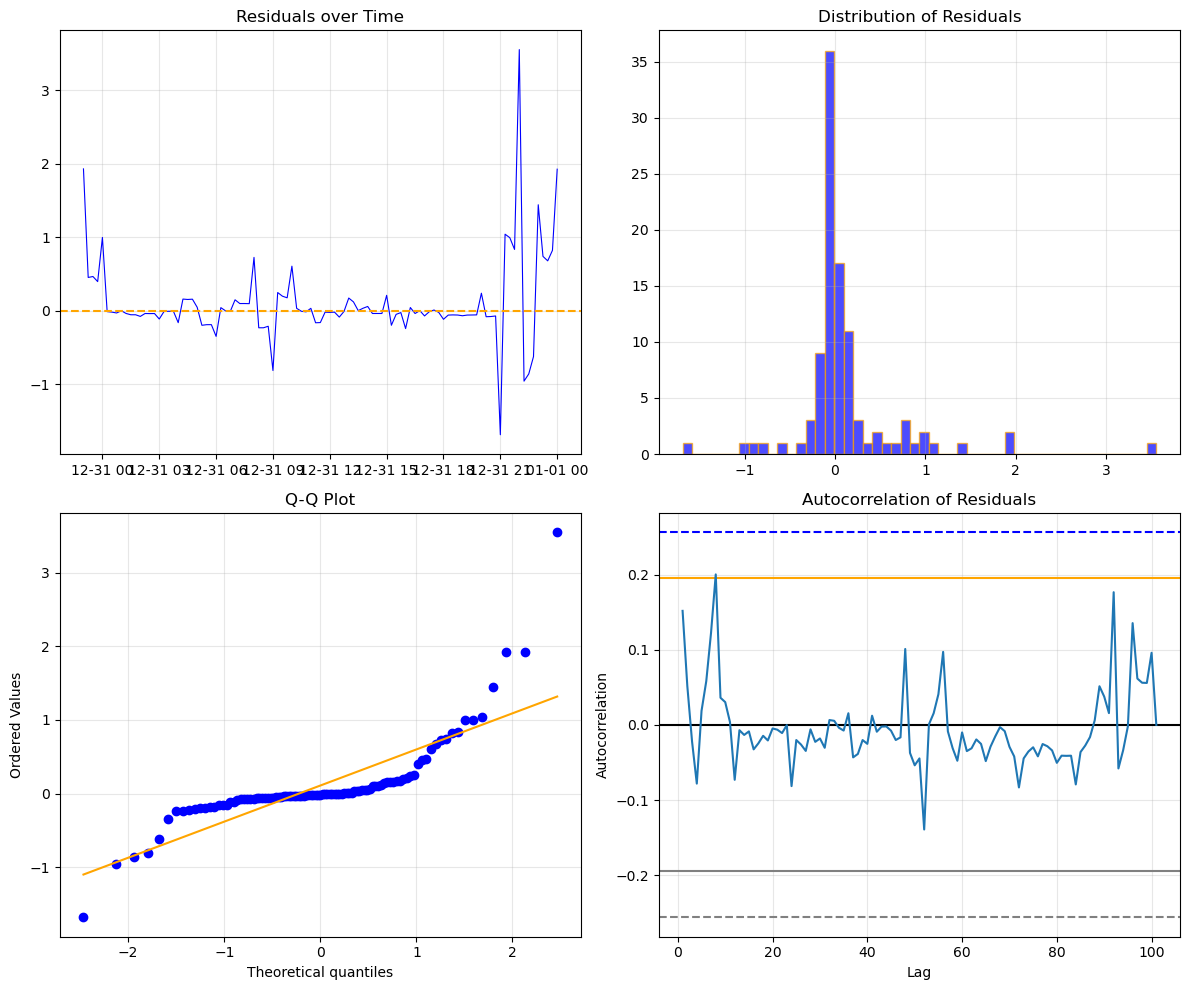

In [11]:
diagnose_model_fit(analyzer.final_df, 'delta_emissions', 'delta_estimated_emissions')

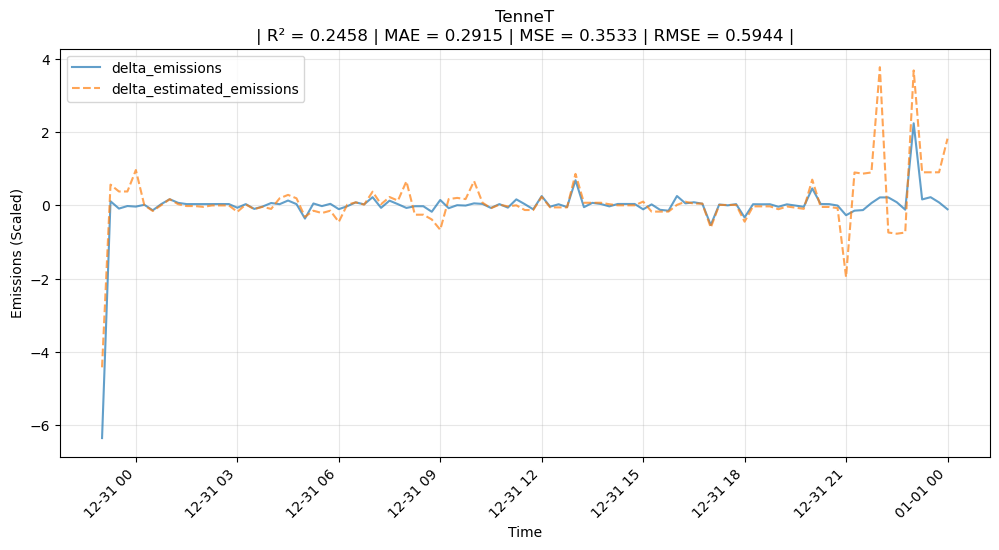

In [12]:
plot_over_time(analyzer.final_df, tso='TenneT', plot=True, col1='delta_emissions', col2='delta_estimated_emissions', y_label='Emissions (Scaled)')

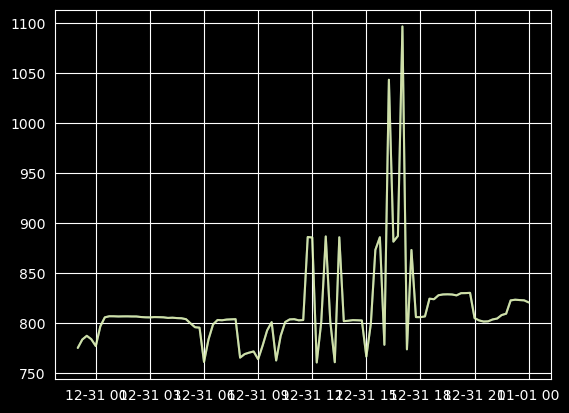

In [14]:
plt.plot(analyzer.final_df.index, analyzer.final_df['mef_g_kWh'], label='MEF', alpha=0.7)
plt.show()

In [15]:
analyzer.params

AttributeError: 'MSARAnalyzer' object has no attribute 'params'